In [ ]:
from google.colab import drive
import pandas as pd

# Monter Google Drive
drive.mount('/content/drive')

# Charger le fichier depuis Drive
df = pd.read_csv('/content/drive/MyDrive/data_science/UK_Accident.csv')

# Vérifier que ça a bien marché
# print(f"✅ Données chargées : {df.shape}")
# print(df.head(5))
print("Colonnes et types :")
print(df.dtypes)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Colonnes et types :
Unnamed: 0                                       int64
Accident_Index                                  object
Location_Easting_OSGR                          float64
Location_Northing_OSGR                         float64
Longitude                                      float64
Latitude                                       float64
Police_Force                                     int64
Accident_Severity                                int64
Number_of_Vehicles                               int64
Number_of_Casualties                             int64
Date                                            object
Day_of_Week                                      int64
Time                                            object
Local_Authority_(District)                       int64
Local_Authority_(Highway)                       object
1st_Road_Class            

In [ ]:
# Vérifier les valeurs manquantes
print(f"\nPourcentage de valeurs manquantes par colonne :")
print((df.isnull().sum() / len(df) * 100).round(2))


Pourcentage de valeurs manquantes par colonne :
Unnamed: 0                                      0.00
Accident_Index                                  0.00
Location_Easting_OSGR                           0.01
Location_Northing_OSGR                          0.00
Longitude                                       0.01
Latitude                                        0.00
Police_Force                                    0.00
Accident_Severity                               0.00
Number_of_Vehicles                              0.00
Number_of_Casualties                            0.00
Date                                            0.00
Day_of_Week                                     0.00
Time                                            0.01
Local_Authority_(District)                      0.00
Local_Authority_(Highway)                       0.00
1st_Road_Class                                  0.00
1st_Road_Number                                 0.00
Road_Type                                       0.

Nous avons fixé un seuil de 20 % pour le traitement des valeurs manquantes : toute colonne présentant plus de 20 % de données manquantes sera supprimée.


In [ ]:
# Définir le seuil (20%)
threshold = 0.2

# Calcul du pourcentage de valeurs manquantes par colonne
missing_ratio = df.isnull().mean()

# Garder uniquement les colonnes avec <= 20% de valeurs manquantes
df_clean = df.loc[:, missing_ratio <= threshold]

# Afficher les colonnes supprimées (optionnel)
dropped_columns = missing_ratio[missing_ratio > threshold].index
print("Colonnes supprimées :", list(dropped_columns))

# Nouveau dataset
df_clean.head()

Colonnes supprimées : ['Junction_Control', 'Special_Conditions_at_Site', 'Carriageway_Hazards']


,Unnamed: 0,Accident_Index,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,...,2nd_Road_Number,Pedestrian_Crossing-Human_Control,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,LSOA_of_Accident_Location,Year
0,0,200501BS00001,525680.0,178240.0,-0.191170,51.489096,1,2,1,1,...,0,None within 50 metres,Zebra crossing,Daylight: Street light present,Raining without high winds,Wet/Damp,1,Yes,E01002849,2005
1,1,200501BS00002,524170.0,181650.0,-0.211708,51.520075,1,3,1,1,...,0,None within 50 metres,Pedestrian phase at traffic signal junction,Darkness: Street lights present and lit,Fine without high winds,Dry,1,Yes,E01002909,2005
2,2,200501BS00003,524520.0,182240.0,-0.206458,51.525301,1,3,2,1,...,0,None within 50 metres,No physical crossing within 50 meters,Darkness: Street lights present and lit,Fine without high winds,Dry,1,Yes,E01002857,2005
3,3,200501BS00004,526900.0,177530.0,-0.173862,51.482442,1,3,1,1,...,0,None within 50 metres,No physical crossing within 50 meters,Daylight: Street light present,Fine without high winds,Dry,1,Yes,E01002840,2005
4,4,200501BS00005,528060.0,179040.0,-0.156618,51.495752,1,3,1,1,...,0,None within 50 metres,No physical crossing within 50 meters,Darkness: Street lighting unknown,Fine without high winds,Wet/Damp,1,Yes,E01002863,2005


In [ ]:
# Colonnes numériques
num_cols = df_clean.select_dtypes(include=['number']).columns.tolist()

# Colonnes catégorielles (object, category, etc.)
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()

# Affichage (optionnel)
print("Colonnes numériques :", num_cols)
print("Colonnes catégorielles :", cat_cols)

Colonnes numériques : ['Unnamed: 0', 'Location_Easting_OSGR', 'Location_Northing_OSGR', 'Longitude', 'Latitude', 'Police_Force', 'Accident_Severity', 'Number_of_Vehicles', 'Number_of_Casualties', 'Day_of_Week', 'Local_Authority_(District)', '1st_Road_Class', '1st_Road_Number', 'Speed_limit', '2nd_Road_Class', '2nd_Road_Number', 'Urban_or_Rural_Area', 'Year']
Colonnes catégorielles : ['Accident_Index', 'Date', 'Time', 'Local_Authority_(Highway)', 'Road_Type', 'Pedestrian_Crossing-Human_Control', 'Pedestrian_Crossing-Physical_Facilities', 'Light_Conditions', 'Weather_Conditions', 'Road_Surface_Conditions', 'Did_Police_Officer_Attend_Scene_of_Accident', 'LSOA_of_Accident_Location']


#Gestion des variables gatégorielles


In [ ]:
# Sélection des colonnes catégorielles
cat_df = df_clean.select_dtypes(include=['object', 'category'])

# Afficher les premières lignes
cat_df.head()

,Accident_Index,Date,Time,Local_Authority_(Highway),Road_Type,Pedestrian_Crossing-Human_Control,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Did_Police_Officer_Attend_Scene_of_Accident,LSOA_of_Accident_Location
0,200501BS00001,04/01/2005,17:42,E09000020,Single carriageway,None within 50 metres,Zebra crossing,Daylight: Street light present,Raining without high winds,Wet/Damp,Yes,E01002849
1,200501BS00002,05/01/2005,17:36,E09000020,Dual carriageway,None within 50 metres,Pedestrian phase at traffic signal junction,Darkness: Street lights present and lit,Fine without high winds,Dry,Yes,E01002909
2,200501BS00003,06/01/2005,00:15,E09000020,Single carriageway,None within 50 metres,No physical crossing within 50 meters,Darkness: Street lights present and lit,Fine without high winds,Dry,Yes,E01002857
3,200501BS00004,07/01/2005,10:35,E09000020,Single carriageway,None within 50 metres,No physical crossing within 50 meters,Daylight: Street light present,Fine without high winds,Dry,Yes,E01002840
4,200501BS00005,10/01/2005,21:13,E09000020,Single carriageway,None within 50 metres,No physical crossing within 50 meters,Darkness: Street lighting unknown,Fine without high winds,Wet/Damp,Yes,E01002863


In [ ]:
# Récupérer les noms des colonnes catégorielles
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns

In [ ]:
for col in cat_cols:
    print(f"Colonne: {col}")

    # Nombre de valeurs uniques
    print("Nombre de valeurs uniques :", df_clean[col].nunique())

Colonne: Accident_Index
Nombre de valeurs uniques : 927387
Colonne: Date
Nombre de valeurs uniques : 3286
Colonne: Time
Nombre de valeurs uniques : 1439
Colonne: Local_Authority_(Highway)
Nombre de valeurs uniques : 207
Colonne: Road_Type
Nombre de valeurs uniques : 6
Colonne: Pedestrian_Crossing-Human_Control
Nombre de valeurs uniques : 3
Colonne: Pedestrian_Crossing-Physical_Facilities
Nombre de valeurs uniques : 6
Colonne: Light_Conditions
Nombre de valeurs uniques : 5
Colonne: Weather_Conditions
Nombre de valeurs uniques : 9
Colonne: Road_Surface_Conditions
Nombre de valeurs uniques : 6
Colonne: Did_Police_Officer_Attend_Scene_of_Accident
Nombre de valeurs uniques : 2
Colonne: LSOA_of_Accident_Location
Nombre de valeurs uniques : 35452


In [ ]:
del_value_list = ['Accident_Index','Local_Authority_(Highway)','LSOA_of_Accident_Location']

cat_cols_new = [col for col in cat_cols if col not in del_value_list]

Colonne: Accident_Index
Nombre de valeurs uniques : 927387


KeyboardInterrupt: 

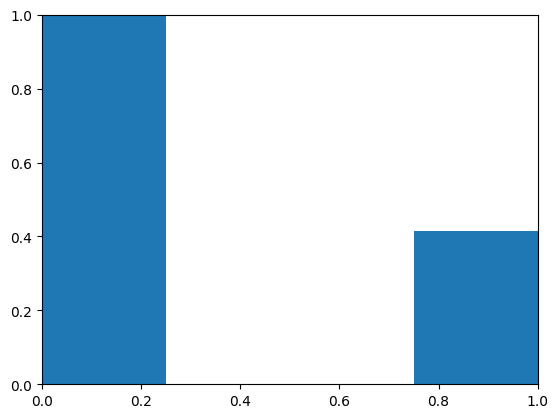

In [ ]:
import matplotlib.pyplot as plt

for col in cat_cols:
    print(f"Colonne: {col}")

    # Nombre de valeurs uniques (sur le sample)
    print("Nombre de valeurs uniques :", df_clean[col].nunique())

    # Distribution en pourcentage
    distribution = df_clean[col].value_counts(normalize=True) * 100

    # Graphique
    plt.figure()
    distribution.plot(kind='bar')

    plt.title(f"Distribution (%) de {col} (sample)")
    plt.xlabel("Catégories")
    plt.ylabel("Pourcentage")
    plt.xticks(rotation=45)

    plt.show()

    print("-" * 50)

D'après les distributions nous allons traiter certaines colonnes:

1.   Time: Créer 3 catégories (00h-08h, 08h-17h, 17h-23h)
2.   Dates: Supprimer parce que nous voulons tirer les jours de la semaines et cette information existe déjà avec la variable day_of_week
3.   Accident_Index: Supprimer





In [ ]:
# Afficher la colonne Time
print("Colonne Time :")
print(df_clean['Time'])

In [ ]:
import numpy as np

# Fonction pour extraire l'heure avec gestion des erreurs
def extraire_heure(time_str):
    try:
        # Vérifier si la valeur est NaN ou non valide
        if pd.isna(time_str):
            return np.nan
        # Convertir en string si ce n'est pas déjà une string
        time_str = str(time_str)
        # Vérifier si le format contient ':'
        if ':' in time_str:
            return int(time_str.split(':')[0])
        else:
            return np.nan
    except:
        return np.nan

# Créer la colonne avec l'heure numérique
df_clean['heure_num'] = df_clean['Time'].apply(extraire_heure)

# Vérifier combien de valeurs manquantes
print(f"Valeurs manquantes dans Time : {df_clean['Time'].isnull().sum()}")
print(f"Valeurs manquantes dans heure_num : {df_clean['heure_num'].isnull().sum()}")

# Fonction pour catégoriser les heures
def categoriser_heure(heure):
    if pd.isna(heure):
        return 'Inconnu'  # Pour les valeurs manquantes
    elif 0 <= heure < 8:
        return '00h-08h'
    elif 8 <= heure < 17:
        return '08h-17h'
    elif 17 <= heure < 23:
        return '17h-23h'
    else:
        return '23h-00h'  # Pour les heures entre 23h et 00h

# Appliquer la catégorisation
df_clean['categorie_horaire'] = df_clean['heure_num'].apply(categoriser_heure)

# Supprimer la colonne 'Dates' si elle existe
if 'Dates' in df_clean.columns:
    df_clean = df_clean.drop('Dates', axis=1)
    print("\nColonne 'Dates' supprimée")

# Supprimer la colonne 'Accident_Index' si elle existe
if 'Accident_Index' in df_clean.columns:
    df_clean = df_clean.drop('Accident_Index', axis=1)
    print("Colonne 'Accident_Index' supprimée")

# Afficher les résultats
print("\n=== Aperçu des données modifiées ===")
print(df_clean[['Time', 'heure_num', 'categorie_horaire']].head(20))

print("\n=== Distribution des catégories horaires ===")
print(df_clean['categorie_horaire'].value_counts().sort_index())

print("\n=== Vérification des valeurs problématiques ===")
valeurs_problematiques = df_clean[df_clean['heure_num'].isna()]
print(f"Nombre de lignes avec heures non valides : {len(valeurs_problematiques)}")
if len(valeurs_problematiques) > 0:
    print("\nExemples de valeurs problématiques :")
    print(valeurs_problematiques['Time'].head(10))

print("\n=== Colonnes restantes ===")
print(df_clean.columns.tolist())

Valeurs manquantes dans Time : 117
Valeurs manquantes dans heure_num : 117
Colonne 'Accident_Index' supprimée

=== Aperçu des données modifiées ===
     Time  heure_num categorie_horaire
0   17:42       17.0           17h-23h
1   17:36       17.0           17h-23h
2   00:15        0.0           00h-08h
3   10:35       10.0           08h-17h
4   21:13       21.0           17h-23h
5   12:40       12.0           08h-17h
6   20:40       20.0           17h-23h
7   17:35       17.0           17h-23h
8   22:43       22.0           17h-23h
9   16:00       16.0           08h-17h
10  00:42        0.0           00h-08h
11  20:48       20.0           17h-23h
12  12:55       12.0           08h-17h
13  05:01        5.0           00h-08h
14  11:15       11.0           08h-17h
15  10:50       10.0           08h-17h
16  00:15        0.0           00h-08h
17  09:15        9.0           08h-17h
18  21:16       21.0           17h-23h
19  03:00        3.0           00h-08h

=== Distribution des catégories 

In [ ]:
# print(df_clean.loc[29084])
# Supprimer toutes les lignes où Time est NaN
df_clean = df_clean.dropna(subset=['Time'])

#Variables numériqes
Nous allons passer au traitement des variables numériques

In [ ]:
# Afficher les colonnes numériques
colonnes_numeriques = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Colonnes numériques :")
print(colonnes_numeriques)

Colonnes numériques :
['Unnamed: 0', 'Location_Easting_OSGR', 'Location_Northing_OSGR', 'Longitude', 'Latitude', 'Police_Force', 'Accident_Severity', 'Number_of_Vehicles', 'Number_of_Casualties', 'Day_of_Week', 'Local_Authority_(District)', '1st_Road_Class', '1st_Road_Number', 'Speed_limit', '2nd_Road_Class', '2nd_Road_Number', 'Urban_or_Rural_Area', 'Year', 'heure_num']


In [ ]:
# Statistiques descriptives des variables numériques
df_clean[colonnes_numeriques].describe()

# Afficher le nombre de valeurs uniques pour chaque variable
for col in colonnes_numeriques:
    print(f"{col}: {df_clean[col].nunique()} valeurs uniques")

Unnamed: 0: 570011 valeurs uniques
Location_Easting_OSGR: 182519 valeurs uniques
Location_Northing_OSGR: 221878 valeurs uniques
Longitude: 1059046 valeurs uniques
Latitude: 1001149 valeurs uniques
Police_Force: 51 valeurs uniques
Accident_Severity: 3 valeurs uniques
Number_of_Vehicles: 27 valeurs uniques
Number_of_Casualties: 47 valeurs uniques
Day_of_Week: 7 valeurs uniques
Local_Authority_(District): 416 valeurs uniques
1st_Road_Class: 6 valeurs uniques
1st_Road_Number: 6854 valeurs uniques
Speed_limit: 8 valeurs uniques
2nd_Road_Class: 7 valeurs uniques
2nd_Road_Number: 7235 valeurs uniques
Urban_or_Rural_Area: 3 valeurs uniques
Year: 9 valeurs uniques
heure_num: 24 valeurs uniques


In [ ]:
# Supprimer la colonne d'index
df_clean = df_clean.drop('Unnamed: 0', axis=1)
print("Colonne 'Unnamed: 0' supprimée")

Colonne 'Unnamed: 0' supprimée


In [ ]:
# Afficher un échantillon des colonnes géographiques
print("=== Aperçu des colonnes géographiques ===")
print(df_clean[['Location_Easting_OSGR', 'Location_Northing_OSGR', 'Longitude', 'Latitude']].head(10))

print("\n=== Statistiques des colonnes OSGR ===")
print(df_clean[['Location_Easting_OSGR', 'Location_Northing_OSGR']].describe())

print("\n=== Statistiques des colonnes Longitude/Latitude ===")
print(df_clean[['Longitude', 'Latitude']].describe())

print("\n=== Types de données ===")
print(df_clean[['Location_Easting_OSGR', 'Location_Northing_OSGR', 'Longitude', 'Latitude']].dtypes)

=== Aperçu des colonnes géographiques ===
   Location_Easting_OSGR  Location_Northing_OSGR  Longitude   Latitude
0               525680.0                178240.0  -0.191170  51.489096
1               524170.0                181650.0  -0.211708  51.520075
2               524520.0                182240.0  -0.206458  51.525301
3               526900.0                177530.0  -0.173862  51.482442
4               528060.0                179040.0  -0.156618  51.495752
5               524770.0                181160.0  -0.203238  51.515540
6               524220.0                180830.0  -0.211277  51.512695
7               525890.0                179710.0  -0.187623  51.502260
8               527350.0                177650.0  -0.167342  51.483420
9               524550.0                180810.0  -0.206531  51.512443

=== Statistiques des colonnes OSGR ===
       Location_Easting_OSGR  Location_Northing_OSGR
count           1.504049e+06            1.504150e+06
mean            4.396214e+05   

In [ ]:
# Supprimer toutes les colonnes de localisation
colonnes_localisation = ['Location_Easting_OSGR', 'Location_Northing_OSGR', 'Longitude', 'Latitude']
df_clean = df_clean.drop(colonnes_localisation, axis=1, errors='ignore')
print("Colonnes de localisation supprimées :")
print(colonnes_localisation)

print(f"\nColonnes restantes : {df_clean.columns.tolist()}")

Colonnes de localisation supprimées :
['Location_Easting_OSGR', 'Location_Northing_OSGR', 'Longitude', 'Latitude']

Colonnes restantes : ['Police_Force', 'Accident_Severity', 'Number_of_Vehicles', 'Number_of_Casualties', 'Date', 'Day_of_Week', 'Time', 'Local_Authority_(District)', 'Local_Authority_(Highway)', '1st_Road_Class', '1st_Road_Number', 'Road_Type', 'Speed_limit', '2nd_Road_Class', '2nd_Road_Number', 'Pedestrian_Crossing-Human_Control', 'Pedestrian_Crossing-Physical_Facilities', 'Light_Conditions', 'Weather_Conditions', 'Road_Surface_Conditions', 'Urban_or_Rural_Area', 'Did_Police_Officer_Attend_Scene_of_Accident', 'LSOA_of_Accident_Location', 'Year', 'heure_num', 'categorie_horaire']


Après avoir fait un premier traitement sur les variables nous allons réduire le nombre de variable à 10 maximum pour avoir un modèle plus rapide et optimisé

In [ ]:
# Afficher les variables numériques
numeriques = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("=== Variables NUMÉRIQUES ===")
print(f"Nombre : {len(numeriques)}")
print(numeriques)

# Afficher les variables catégorielles
categorielles = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
print("\n=== Variables CATÉGORIELLES ===")
print(f"Nombre : {len(categorielles)}")
print(categorielles)

=== Variables NUMÉRIQUES ===
Nombre : 14
['Police_Force', 'Accident_Severity', 'Number_of_Vehicles', 'Number_of_Casualties', 'Day_of_Week', 'Local_Authority_(District)', '1st_Road_Class', '1st_Road_Number', 'Speed_limit', '2nd_Road_Class', '2nd_Road_Number', 'Urban_or_Rural_Area', 'Year', 'heure_num']

=== Variables CATÉGORIELLES ===
Nombre : 12
['Date', 'Time', 'Local_Authority_(Highway)', 'Road_Type', 'Pedestrian_Crossing-Human_Control', 'Pedestrian_Crossing-Physical_Facilities', 'Light_Conditions', 'Weather_Conditions', 'Road_Surface_Conditions', 'Did_Police_Officer_Attend_Scene_of_Accident', 'LSOA_of_Accident_Location', 'categorie_horaire']


In [ ]:
# Liste des variables à supprimer
del_value_list = ['Accident_Index', 'Local_Authority_(Highway)', 'LSOA_of_Accident_Location', 'Local_Authority_(District)', 'Date','Time']

# Supprimer les colonnes
df_clean = df_clean.drop(columns=del_value_list, errors='ignore')

print("Variables supprimées :")
print(del_value_list)

# Afficher les colonnes restantes
print(f"\nColonnes restantes : {df_clean.columns.tolist()}")

Variables supprimées :
['Accident_Index', 'Local_Authority_(Highway)', 'LSOA_of_Accident_Location', 'Local_Authority_(District)', 'Date', 'Time']

Colonnes restantes : ['Police_Force', 'Accident_Severity', 'Number_of_Vehicles', 'Number_of_Casualties', 'Day_of_Week', '1st_Road_Class', '1st_Road_Number', 'Road_Type', 'Speed_limit', '2nd_Road_Class', '2nd_Road_Number', 'Pedestrian_Crossing-Human_Control', 'Pedestrian_Crossing-Physical_Facilities', 'Light_Conditions', 'Weather_Conditions', 'Road_Surface_Conditions', 'Urban_or_Rural_Area', 'Did_Police_Officer_Attend_Scene_of_Accident', 'Year', 'heure_num', 'categorie_horaire']


In [ ]:
# Afficher les colonnes catégorielles
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print("Colonnes catégorielles à encoder :")
print(cat_cols)

Colonnes catégorielles à encoder :
['Road_Type', 'Pedestrian_Crossing-Human_Control', 'Pedestrian_Crossing-Physical_Facilities', 'Light_Conditions', 'Weather_Conditions', 'Road_Surface_Conditions', 'Did_Police_Officer_Attend_Scene_of_Accident', 'categorie_horaire']


In [ ]:
# Appliquer One-Hot Encoding aux variables catégorielles
df_clean = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

print(f"Nouvelles colonnes après encodage : {len(df_clean.columns)}")
print(f"\nPremières colonnes : {df_clean.columns.tolist()[:10]}")

Nouvelles colonnes après encodage : 47

Premières colonnes : ['Police_Force', 'Accident_Severity', 'Number_of_Vehicles', 'Number_of_Casualties', 'Day_of_Week', '1st_Road_Class', '1st_Road_Number', 'Speed_limit', '2nd_Road_Class', '2nd_Road_Number']


In [ ]:
# Séparer X et y
X = df_clean.drop('Accident_Severity', axis=1)
y = df_clean['Accident_Severity']

print(f"Shape de X : {X.shape}")
print(f"Nombre de variables : {len(X.columns)}")
print(f"Shape de y : {y.shape}")

Shape de X : (1504150, 46)
Nombre de variables : 46
Shape de y : (1504150,)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Entraîner le modèle (prendre un échantillon plus petit pour aller plus vite)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

# Afficher les 10 variables les plus importantes
importances = pd.DataFrame({
    'variable': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 variables les plus importantes :")
print(importances.head(10))

Top 10 variables les plus importantes :
                variable  importance
5        1st_Road_Number    0.176218
0           Police_Force    0.169499
10                  Year    0.117736
11             heure_num    0.112448
3            Day_of_Week    0.107243
8        2nd_Road_Number    0.039017
4         1st_Road_Class    0.035490
1     Number_of_Vehicles    0.035246
2   Number_of_Casualties    0.030204
6            Speed_limit    0.026700


In [ ]:
# Sélectionner les 10 meilleures variables
top_10_variables = importances.head(10)['variable'].tolist()

# Créer le dataset final
df_final = df_clean[top_10_variables + ['Accident_Severity']]

print("=== Dataset final avec les 10 meilleures variables ===")
print(f"Shape : {df_final.shape}")
print(f"\nVariables retenues :")
for i, var in enumerate(top_10_variables, 1):
    print(f"{i}. {var}")

=== Dataset final avec les 10 meilleures variables ===
Shape : (1504150, 11)

Variables retenues :
1. 1st_Road_Number
2. Police_Force
3. Year
4. heure_num
5. Day_of_Week
6. 2nd_Road_Number
7. 1st_Road_Class
8. Number_of_Vehicles
9. Number_of_Casualties
10. Speed_limit


In [ ]:
# Afficher les statistiques descriptives
print("=== Statistiques descriptives du dataset final ===")
print(df_final.describe())

# Afficher la distribution de la target
print("\n=== Distribution de Accident_Severity ===")
print(df_final['Accident_Severity'].value_counts())
print("\nPourcentages :")
print(df_final['Accident_Severity'].value_counts(normalize=True) * 100)

=== Statistiques descriptives du dataset final ===
       1st_Road_Number  Police_Force          Year     heure_num  \
count     1.504150e+06  1.504150e+06  1.504150e+06  1.504033e+06   
mean      1.009919e+03  3.020536e+01  2.009370e+03  1.358031e+01   
std       1.823518e+03  2.551603e+01  3.013497e+00  5.144329e+00   
min      -1.000000e+00  1.000000e+00  2.005000e+03  0.000000e+00   
25%       0.000000e+00  6.000000e+00  2.006000e+03  1.000000e+01   
50%       1.290000e+02  3.000000e+01  2.010000e+03  1.400000e+01   
75%       7.250000e+02  4.500000e+01  2.012000e+03  1.700000e+01   
max       9.999000e+03  9.800000e+01  2.014000e+03  2.300000e+01   

        Day_of_Week  2nd_Road_Number  1st_Road_Class  Number_of_Vehicles  \
count  1.504150e+06     1.504150e+06    1.504150e+06        1.504150e+06   
mean   4.118607e+00     3.815684e+02    4.087999e+00        1.831606e+00   
std    1.924405e+00     1.302555e+03    1.428936e+00        7.147586e-01   
min    1.000000e+00    -1.000000

================================================================================
SÉLECTION DES VARIABLES POUR LA PRÉDICTION DE Accident_Severity
================================================================================

Processus de sélection :
1. Encodage des variables catégorielles (One-Hot Encoding)
2. Entraînement d'un Random Forest sur 1.5M d'accidents
3. Extraction de l'importance des 45 variables
4. Conservation des 10 variables les plus importantes

Variables sélectionnées (par ordre d'importance) :
1. 1st_Road_Number        - Numéro de la route principale
2. Police_Force           - Zone de police
3. Year                   - Année de l'accident
4. heure_num              - Heure de l'accident (0-23h)
5. Day_of_Week            - Jour de la semaine
6. 2nd_Road_Number        - Numéro de la route secondaire
7. 1st_Road_Class         - Classe de la route principale
8. Number_of_Vehicles     - Nombre de véhicules impliqués
9. Number_of_Casualties   - Nombre de victimes
10. Speed_limit           - Limitation de vitesse

Ces 10 variables expliquent le mieux la sévérité des accidents.
Le modèle de régression logistique atteint une accuracy de 85.11%.

================================================================================
"""

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Séparer X et y
X = df_final.drop('Accident_Severity', axis=1)
y = df_final['Accident_Severity']

# Diviser en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train shape : {X_train.shape}")
print(f"Test shape : {X_test.shape}")

# Normaliser les données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nDonnées normalisées avec succès")

Train shape : (1203320, 10)
Test shape : (300830, 10)

Données normalisées avec succès


In [ ]:
# Supprimer les lignes avec des valeurs manquantes
print(f"Taille avant suppression des NaN : {len(df_final)}")
df_final = df_final.dropna()
print(f"Taille après suppression des NaN : {len(df_final)}")

# Vérifier qu'il n'y a plus de NaN
print(f"Valeurs manquantes restantes : {df_final.isnull().sum().sum()}")

Taille avant suppression des NaN : 1504150
Taille après suppression des NaN : 1504033
Valeurs manquantes restantes : 0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Séparer X et y
X = df_final.drop('Accident_Severity', axis=1)
y = df_final['Accident_Severity']

# Diviser en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normaliser
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entraîner la régression logistique
log_reg = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
log_reg.fit(X_train_scaled, y_train)

# Prédictions et évaluation
y_pred = log_reg.predict(X_test_scaled)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

Accuracy : 0.8511
              precision    recall  f1-score   support

           1       0.21      0.00      0.00      3888
           2       0.41      0.00      0.00     40897
           3       0.85      1.00      0.92    256022

    accuracy                           0.85    300807
   macro avg       0.49      0.33      0.31    300807
weighted avg       0.78      0.85      0.78    300807



In [ ]:
from imblearn.over_sampling import SMOTE

# Appliquer SMOTE pour rééquilibrer les classes
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"Avant SMOTE - Distribution :")
print(y_train.value_counts())
print(f"\nAprès SMOTE - Distribution :")
print(pd.Series(y_train_balanced).value_counts())

Avant SMOTE - Distribution :
Accident_Severity
3    1024087
2     163587
1      15552
Name: count, dtype: int64

Après SMOTE - Distribution :
Accident_Severity
3    1024087
2    1024087
1    1024087
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Recréer df_final avec les 10 meilleures variables
top_10_variables = ['1st_Road_Number', 'Police_Force', 'Year', 'heure_num',
                    'Day_of_Week', '2nd_Road_Number', '1st_Road_Class',
                    'Number_of_Vehicles', 'Number_of_Casualties', 'Speed_limit']

df_final = df_clean[top_10_variables + ['Accident_Severity']]

print(f"Taille de df_final : {len(df_final)}")

# Échantillonner 50,000 lignes de manière stratifiée
df_sample, _ = train_test_split(df_final, train_size=150000, random_state=42, stratify=df_final['Accident_Severity'])

# === NOUVEAU : Supprimer les NaN ===
print(f"\nTaille avant suppression des NaN : {len(df_sample)}")
print("Valeurs manquantes par colonne :")
print(df_sample.isnull().sum())

df_sample = df_sample.dropna()
print(f"\nTaille après suppression des NaN : {len(df_sample)}")
print(f"Valeurs manquantes restantes : {df_sample.isnull().sum().sum()}")

# Distribution après nettoyage
print(f"\nDistribution dans l'échantillon :")
print(df_sample['Accident_Severity'].value_counts())

# Séparer X et y
X_sample = df_sample.drop('Accident_Severity', axis=1)
y_sample = df_sample['Accident_Severity']

# Diviser en train/test
X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42, stratify=y_sample)

# Normaliser
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Appliquer SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"\nAprès SMOTE - Distribution :")
print(pd.Series(y_train_balanced).value_counts())

# Entraîner la régression logistique
log_reg_balanced = LogisticRegression(max_iter=1000, random_state=42)
log_reg_balanced.fit(X_train_balanced, y_train_balanced)

# Prédictions
y_pred_balanced = log_reg_balanced.predict(X_test_scaled)

# Évaluation
print("\n=== Performance après SMOTE (échantillon 50k) ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_balanced):.4f}")
print(f"\nClassification Report :")
print(classification_report(y_test, y_pred_balanced))

Taille de df_final : 1504150

Taille avant suppression des NaN : 150000
Valeurs manquantes par colonne :
1st_Road_Number          0
Police_Force             0
Year                     0
heure_num               13
Day_of_Week              0
2nd_Road_Number          0
1st_Road_Class           0
Number_of_Vehicles       0
Number_of_Casualties     0
Speed_limit              0
Accident_Severity        0
dtype: int64

Taille après suppression des NaN : 149987
Valeurs manquantes restantes : 0

Distribution dans l'échantillon :
Accident_Severity
3    127659
2     20390
1      1938
Name: count, dtype: int64

Après SMOTE - Distribution :
Accident_Severity
3    102127
2    102127
1    102127
Name: count, dtype: int64

=== Performance après SMOTE (échantillon 50k) ===
Accuracy : 0.4988

Classification Report :
              precision    recall  f1-score   support

           1       0.03      0.59      0.06       388
           2       0.17      0.33      0.23      4078
           3       0.90    

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Entraîner un Random Forest (plus puissant que la régression logistique)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
rf.fit(X_train_balanced, y_train_balanced)

# Prédictions
y_pred_rf = rf.predict(X_test_scaled)

# Évaluation
print("=== Performance Random Forest ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"\nClassification Report :")
print(classification_report(y_test, y_pred_rf))

In [ ]:
from google.colab import files

# Convertir en CSV et télécharger
df_sample.to_csv('df_sample.csv', index=False)
files.download('df_sample.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>